In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

In [60]:
df = pd.read_csv('../data/raw/rice_prices.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.head()

,date,price
0,2015-01-04,202.483571
1,2015-01-11,200.406509
2,2015-01-18,205.420958
3,2015-01-25,210.856216
4,2015-02-01,203.090046


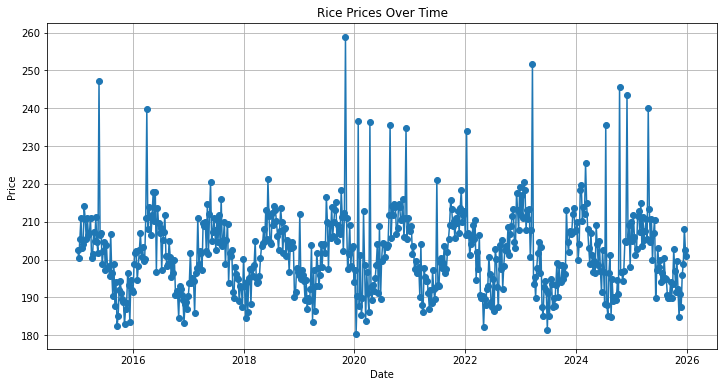

In [61]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['price'], marker='o')
plt.title('Rice Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [62]:
cap_value = df['price'].quantile(0.99)
df['price_capped'] = np.where(df['price'] > cap_value, cap_value, df['price'])

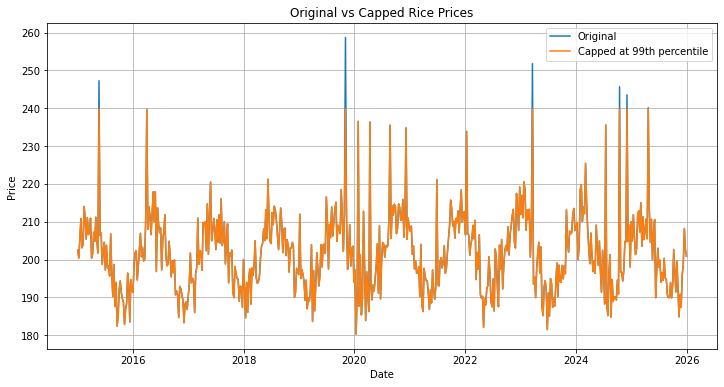

In [63]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['price'], label='Original')
plt.plot(df['date'], df['price_capped'], label='Capped at 99th percentile')
plt.title('Original vs Capped Rice Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
train = df['price_capped'][:-4]
test = df['price_capped'][-4:]

In [65]:
model_arima = ARIMA(train, order=(2,1,2))
model_arima_fit = model_arima.fit()

In [66]:
forecast_arima = model_arima_fit.forecast(steps=4)
print("ARIMA Forecast:", forecast_arima.values)

ARIMA Forecast: [192.39688243 191.78615359 191.4571403  191.20909488]


In [67]:
mape_arima = mean_absolute_percentage_error(test, forecast_arima)
print("ARIMA MAPE:", round(mape_arima*100, 2), "%")

ARIMA MAPE: 5.35 %


In [68]:
prophet_df = df[['date','price_capped']].rename(columns={'date':'ds','price_capped':'y'})

In [69]:
model_prophet = Prophet()
model_prophet.fit(prophet_df[:-4])

23:57:51 - cmdstanpy - INFO - Chain [1] start processing
23:57:51 - cmdstanpy - INFO - Chain [1] done processing


In [70]:
future = model_prophet.make_future_dataframe(periods=4, freq='W')
forecast_prophet = model_prophet.predict(future)

In [71]:
prophet_pred = forecast_prophet['yhat'][-4:].values
print("Prophet Forecast:", prophet_pred)

Prophet Forecast: [202.66236924 202.31299736 201.6470513  201.26915751]


In [72]:
mape_prophet = mean_absolute_percentage_error(test, prophet_pred)
print("Prophet MAPE:", round(mape_prophet*100, 2), "%")

Prophet MAPE: 1.34 %


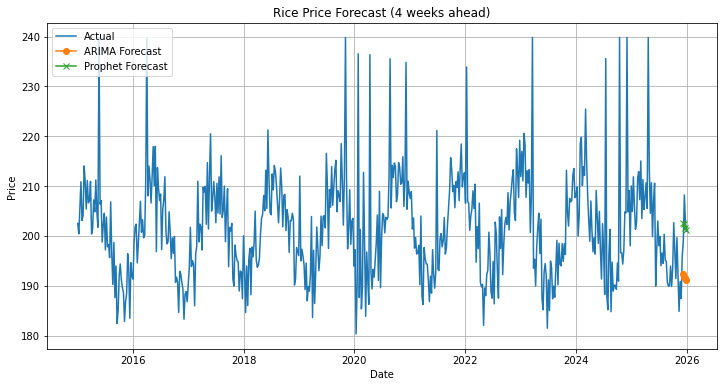

In [73]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['price_capped'], label='Actual')
plt.plot(df['date'][-4:], forecast_arima.values, marker='o', label='ARIMA Forecast')
plt.plot(df['date'][-4:], prophet_pred, marker='x', label='Prophet Forecast')
plt.title('Rice Price Forecast (4 weeks ahead)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
